# 2D Extrapolation with `geoPFA`: Example from Newberry Volcano, OR
This tutorial demonstrates how to use the `Processing.extrapolate_2d` as part of the **data processing workflow** in `geoPFA`.

In this example, we extrapolate velocity model data so that it matches the 2D extent of a MT Reseistivity data layer that covers more of a region of interest.


For a more detailed tutorial on the broader **data processing workflow** in `geoPFA`, please refer to the `1-processing_newberry.ipynb` notebook.

## 1. Imports and Setup

In [ ]:
# --- General imports ---
from pathlib import Path
import geopandas as gpd

# --- geoPFA core classes ---
from geopfa.io.data_readers import GeospatialDataReaders
from geopfa.processing import Cleaners, Processing
from geopfa.plotters import GeospatialDataPlotters

# --- Utilities ---
from geopfa.io.data_readers import safe_json_load
import json

### Define Directories

In [2]:
# Get the directory where this notebook lives
notebook_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()

# Define the main project directory (where 'config/', 'data/', and 'notebooks/' live)
project_dir = notebook_dir.parent

# Define subdirectories
config_dir = project_dir / "config"
data_dir = project_dir / "data"

# Confirm structure
print("Notebook directory:", notebook_dir)
print("Config directory:", config_dir)
print("Data directory:", data_dir)

# Quick check before proceeding
for folder in [config_dir, data_dir]:
    if not folder.exists():
        raise FileNotFoundError(f"Expected folder not found: {folder}")

Notebook directory: c:\Users\smello\code\geoPFA\examples\Newberry\2D\notebooks
Config directory: c:\Users\smello\code\geoPFA\examples\Newberry\2D\config
Data directory: c:\Users\smello\code\geoPFA\examples\Newberry\2D\data


## 2. Configuration and Data Input
With the project directories defined, the next step is to **read the configuration file** and **load all raw geospatial data** into memory.

### Read configuration file

In [ ]:
# Path to configuration file
pfa_path = config_dir / "newberry_extrapolation_example_config.json"

# Load JSON configuration safely (handles comments and malformed JSON)
pfa = safe_json_load(str(pfa_path))

Successfully loaded JSON file from: c:\Users\smello\code\geoPFA\examples\Newberry\2D\config\newberry_superhot_config.json


### Load data into the `pfa` dictionary

In [4]:
# Define the file types to be read (others will be skipped with a warning)
file_types = [".csv", ".shp"]

# Gather data according to the config structure
pfa = GeospatialDataReaders.gather_data(
    data_dir,
    pfa,
    file_types,
    validate=True
)

criteria: geologic
	 component: heat
		 reading layer: density_joint_inv
		 reading layer: mt_resistivity_joint_inv
		 reading layer: temperature_model_500m
		 reading layer: earthquakes
		 reading layer: velocity_model_vs
		 reading layer: velocity_model_vpvs
	 component: reservoir
		 reading layer: lineaments
		 reading layer: density_joint_inv
		 reading layer: mt_resistivity_joint_inv
		 reading layer: earthquakes
		 reading layer: velocity_model_vs
		 reading layer: velocity_model_vpvs
	 component: insulation
		 reading layer: density_joint_inv
		 reading layer: mt_resistivity_joint_inv
		 reading layer: earthquakes
		 reading layer: temperature_model_500m
		 reading layer: velocity_model_vp

All layers contain valid 'data'.


## 3. Harmonizing Data

### Define the Target CRS and Import Contextual Data

In [ ]:
# EPSG code for UTM Zone 10N (meters)
target_crs = 26910
# Define grid resolution (number of cells in x and y)
nx = 300; ny = 300

# Load the project boundary shapefile
outline_path = data_dir / "supporting_data" / "national_monument_boundary" / "NNVM_bounds.shp"
outline = gpd.read_file(outline_path).to_crs(target_crs)

print(f"Loaded boundary: {outline_path.name}")

Loaded boundary: NNVM_bounds.shp


### Unify CRS and Define Extent
CRS is defined manually using the variable `target_crs` defined above. 

Extent is defined using an existing layer. Here we define the extent as the extent of `mt_resistivity_joint_inv`. That extent is larger than the extent of our velocity model data (`velocity_model_vpvs`, `velocity_model_vp`, and `velocity_model_vs`). In the example, we will be extrapolating the velocity model data so that it extends out to that of `mt_resistivity_joint_inv`. 

We compare the extents below.

In [ ]:
# Reproject all layers to the target CRS
pfa = Cleaners.set_crs(pfa, target_crs=target_crs)

# Choose one representative layer to define the spatial extent
target_extent_layer = (
    pfa["criteria"]["geologic"]["components"]["heat"]["layers"]["mt_resistivity_joint_inv"]["data"]
)

small_extent_layer = (
    pfa["criteria"]["geologic"]["components"]["heat"]["layers"]["velocity_model_vpvs"]["data"]
)

# Get extent lists. In 2D that is [xmin, ymin, xmax, ymax]
extent = Cleaners.get_extent(target_extent_layer, dim=2)  # Ensure we grab the 2d extent from 3d data
small_extent = Cleaners.get_extent(small_extent_layer, dim=2)  # Ensure we grab the 2d extent from 3d data

print(f"Big (target) extent: [xmin, ymin, xmax, ymax] = {extent}")
print(f"Small extent: [xmin, ymin, xmax, ymax] = {small_extent}")

[-121.45460790314895, 43.565391146781344, -121.0951183893652, 43.840335199851104]


## 4. Convert 3D Layers to 2D

In [7]:
# Define the active criterion (geologic only in this example)
criteria = "geologic"

# Cache to store flattened layers and reuse them
flattened_layers = {}

for component, comp_data in pfa["criteria"][criteria]["components"].items():
    for layer, layer_config in comp_data["layers"].items():
        is_3d = layer_config.get("is_3d", None)
        needs_flattening = layer_config.get("needs_flattening", "yes")

        # Skip layers not flagged as 3D or marked "no" for flattening
        if not is_3d or str(needs_flattening).lower() == "no":
            continue

        # Use the layer name as the unique cache key
        key = layer

        if key in flattened_layers:
            print(f"Reusing flattened layer: {layer} for component: {component}")
            # Copy cached flattened layer into current component/layer
            pfa["criteria"][criteria]["components"][component]["layers"][layer] = (
                flattened_layers[key].copy()
            )
            continue

        print(f"Converting 3D layer: {layer} → 2D")

        # Perform flattening and store in PFA
        pfa = Processing.convert_3d_to_2d(pfa, criteria, component=component, layer=layer)

        # Cache the flattened result for reuse
        flattened_layers[key] = (
            pfa["criteria"][criteria]["components"][component]["layers"][layer].copy()
        )

print("3D → 2D flattening complete.")

Converting 3D layer: density_joint_inv → 2D
Converting 3D layer: mt_resistivity_joint_inv → 2D
Converting 3D layer: temperature_model_500m → 2D
Converting 3D layer: velocity_model_vs → 2D
Converting 3D layer: velocity_model_vpvs → 2D
Reusing flattened layer: density_joint_inv for component: reservoir
Reusing flattened layer: mt_resistivity_joint_inv for component: reservoir
Reusing flattened layer: velocity_model_vs for component: reservoir
Reusing flattened layer: velocity_model_vpvs for component: reservoir
Reusing flattened layer: density_joint_inv for component: insulation
Reusing flattened layer: mt_resistivity_joint_inv for component: insulation
Reusing flattened layer: temperature_model_500m for component: insulation
Converting 3D layer: velocity_model_vp → 2D
3D → 2D flattening complete.


### Visualize Cleaned Raw Data Layers
`geoPFA` has built-in plotting tools to help visualize data. Let's plot the MT data, which has our target extent, alongside the velocity models we plan to extraplote.

#### Plot All Layers

geologic
	heat


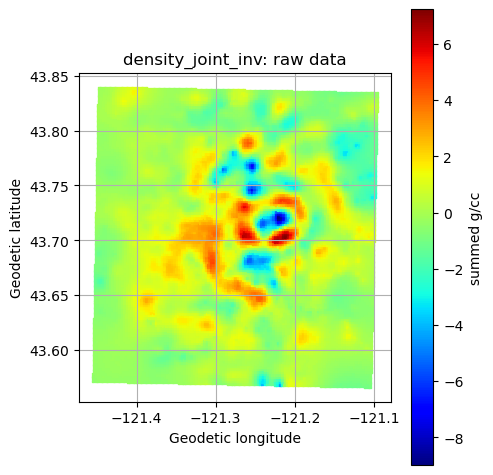

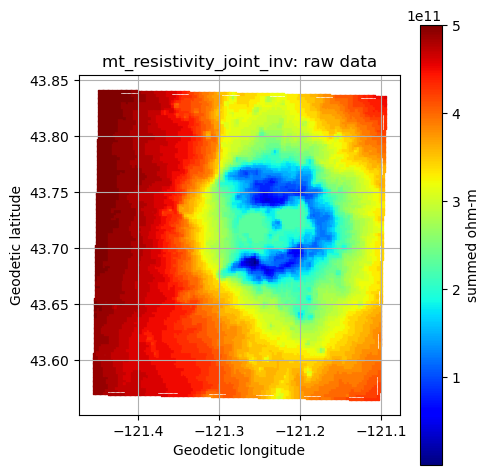

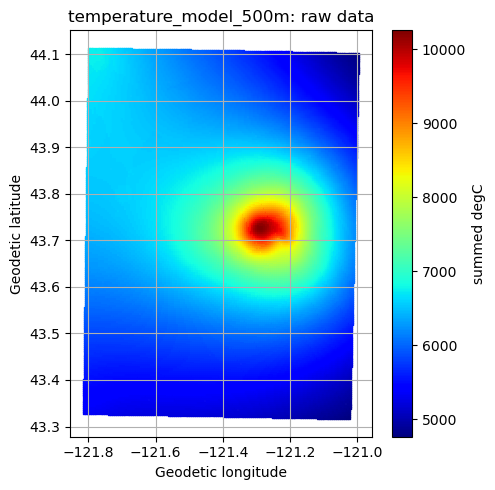

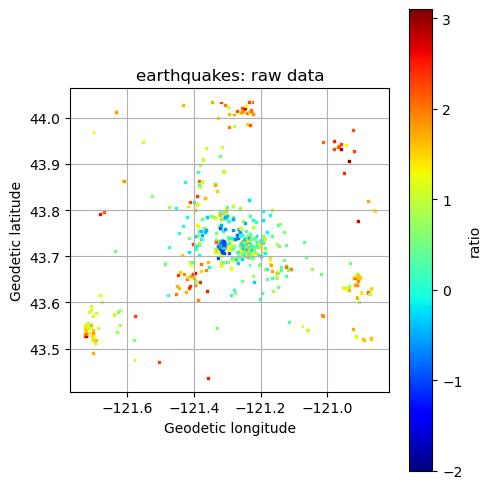

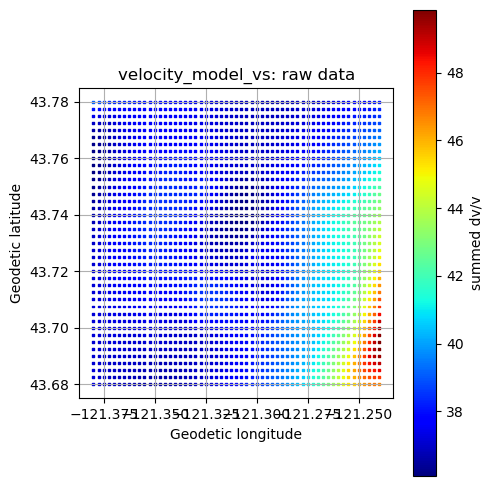

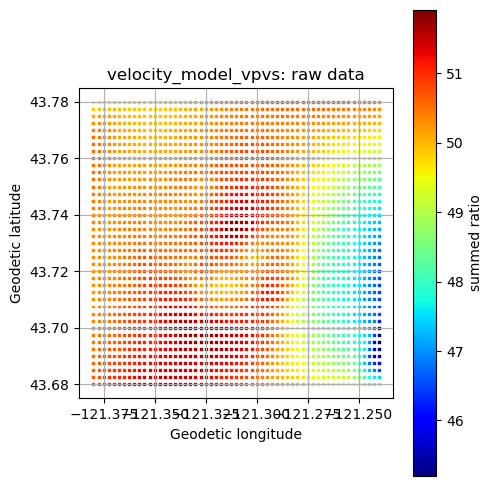

	reservoir
		density_joint_inv plotted already
		mt_resistivity_joint_inv plotted already
		earthquakes plotted already


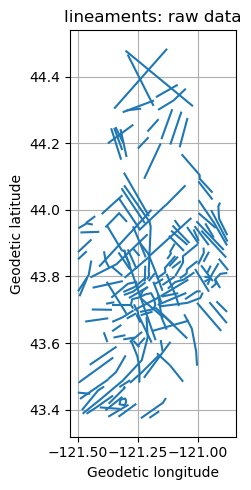

		velocity_model_vs plotted already
		velocity_model_vpvs plotted already
	insulation
		density_joint_inv plotted already
		mt_resistivity_joint_inv plotted already
		earthquakes plotted already
		temperature_model_500m plotted already


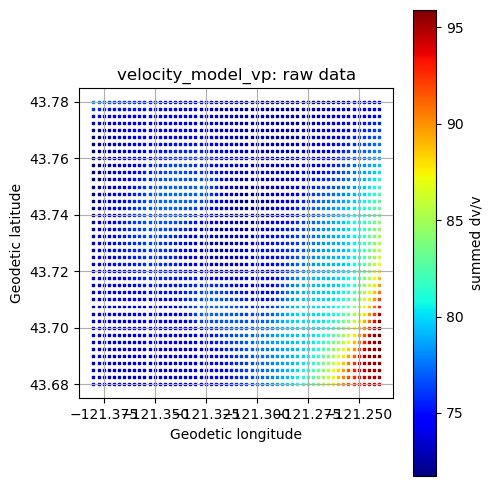

In [9]:
for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    plotted_layers = []
    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")
        for layer, layer_data in comp_data["layers"].items():
            if layer in plotted_layers:
                print(f"\t\t{layer} plotted already")
                continue

            gdf = layer_data["data"]
            col = layer_data.get("data_col", None)
            if layer == "faults_newberry":
                col = "None"  # faults are geometries only

            units = layer_data["units"]
            title = f"{layer}: raw data"

            GeospatialDataPlotters.geo_plot(gdf, col, units, title, markersize=2, figsize=(5, 5))
            plotted_layers.append(layer)

## 5. Data Processing and Preparation

### Filter Outliers

In [10]:
# Filter the upper 10% of values in selected datasets
target_layers = []

for layer in target_layers:
    for component in ["heat", "reservoir"]:
        gdf = pfa["criteria"][criteria]["components"]["heat"]["layers"][layer]["data"]
        col = pfa["criteria"][criteria]["components"]["heat"]["layers"][layer]["data_col"]

        filtered = Cleaners.filter_geodataframe(gdf, col, quantile=0.9)
        pfa["criteria"][criteria]["components"][component]["layers"][layer]["data"] = filtered

print("Outlier filtering complete.")

Outlier filtering complete.


### Extrapolation
`geoPFA` can perform extrapolation over each layer to ensure every layer fills the complete extent. `geoPFA` uses a sparse Gaussian process regression (GPR) model to backfill missing data. Extrapolation works best when the extent of the missing data is relatively small compared to the known data. For large areas, `geoPFA` reverst to a linear trend across the training site to produce essentially the average spatial proess of the known data.

For large datasets, extrapolation can take substanial processing time to complete. Users can improve model fitting time by reducing the `training_size`. Datasets with relatively complete information will benefit greatly from reduced training sizes and should see little reduction in performance. An optional `verbose` flag will enable model assessment and reporting along with model diagnostic and final prediction plots.

In [11]:
target_layers = ['velocity_model_vp','velocity_model_vs','velocity_model_vpvs']
extrapolated_layers = {}

for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")
        for layer, layer_config in comp_data["layers"].items():
            if layer in extrapolated_layers:
                print(f"\t\tReusing cached extrapolation for {layer}")
                pfa["criteria"][criteria]["components"][component][
                    "layers"
                ][layer] = extrapolated_layers[layer].copy()
            elif layer in target_layers:
                print(f"\t\tExtrapolating layer: {layer}")

                gdf = "data"
                col = pfa["criteria"][criteria]["components"][component]["layers"][layer]["data_col"]

                pfa = Processing.extrapolate_2d(
                    pfa,
                    criteria=criteria,
                    component=component,
                    layer=layer,
                    dataset=gdf,
                    data_col=col,
                    training_size=0.8,
                    verbose=False,
                )
                extrapolated_layers[layer] = pfa["criteria"][criteria][
                    "components"
                ][component]["layers"][layer].copy()
            else:
                continue

geologic
	heat
		Extrapolating layer: velocity_model_vs


reconstraining parameters rbf.variance
reconstraining parameters rbf.variance
reconstraining parameters rbf.lengthscale
reconstraining parameters Mat32.variance
reconstraining parameters Mat32.variance
reconstraining parameters Mat32.lengthscale
 c:\Users\smello\code\geoPFA\.pixi\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning:
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

reconstraining parameters sparse_gp.Gaussian_noise.variance
reconstraining parameters sparse_gp.Gaussian_noise.variance
 c:\Users\smello\code\geoPFA\.pixi\envs\default\Lib\site-packages\GPy\core\gp.py:286: SyntaxWarning:invalid escape seque

MemoryError: Unable to allocate 7.57 GiB for an array with shape (186, 5459232) and data type float64

### Interpolation
For most datasets, data can be processed and prepared for layer combination and favorability estimation by simply interpolating data to the target grid. Here we do that only once for each input layer that has `"processing_method": "interpolate"` specified in the configuration file.

This for loop is useful when interpolating many datasets. In this example, it only interpolates the MT Resistivity data

In [ ]:
method = 'linear'

interpolated_layers = {}

for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")
        for layer, layer_config in comp_data["layers"].items():
            if layer_config.get("processing_method") == "interpolate":
                if layer in interpolated_layers:
                    print(f"\t\tReusing cached interpolation for {layer}")
                    pfa["criteria"][criteria]["components"][component]["layers"][layer]['model'] = (
                        interpolated_layers[layer]['model'].copy()
                    )
                    pfa["criteria"][criteria]["components"][component]["layers"][layer]['model_data_col'] = (
                        interpolated_layers[layer]['model_data_col']
                    )
                    pfa["criteria"][criteria]["components"][component]["layers"][layer]['model_units'] = (
                        interpolated_layers[layer]['model_units']
                    )
                else:
                    print(f"\t\tInterpolating layer: {layer}")
                    pfa = Processing.interpolate_points(
                        pfa,
                        criteria=criteria,
                        component=component,
                        layer=layer,
                        interp_method=method,
                        nx=nx,
                        ny=ny,
                        extent=extent,
                    )
                    interpolated_layers[layer] = (
                        pfa["criteria"][criteria]["components"][component]["layers"][layer].copy()
                    )


geologic
	heat
		Interpolating layer: density_joint_inv
		Interpolating layer: mt_resistivity_joint_inv
		Interpolating layer: temperature_model_500m
		Interpolating layer: velocity_model_vs
		Interpolating layer: velocity_model_vpvs
	reservoir
		Reusing cached interpolation for density_joint_inv
		Reusing cached interpolation for mt_resistivity_joint_inv
		Reusing cached interpolation for velocity_model_vs
		Reusing cached interpolation for velocity_model_vpvs
	insulation
		Reusing cached interpolation for density_joint_inv
		Reusing cached interpolation for mt_resistivity_joint_inv
		Reusing cached interpolation for temperature_model_500m
		Interpolating layer: velocity_model_vp


### Plot All Processed Layers

geologic
	heat


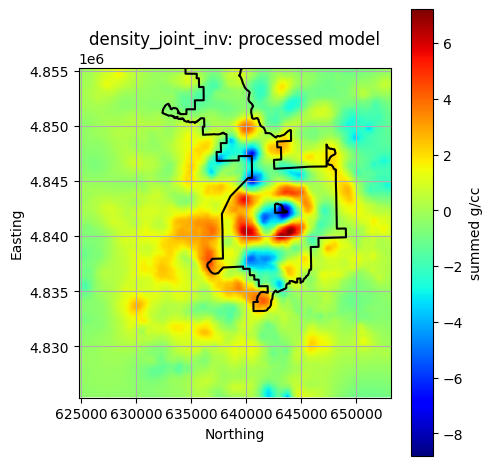

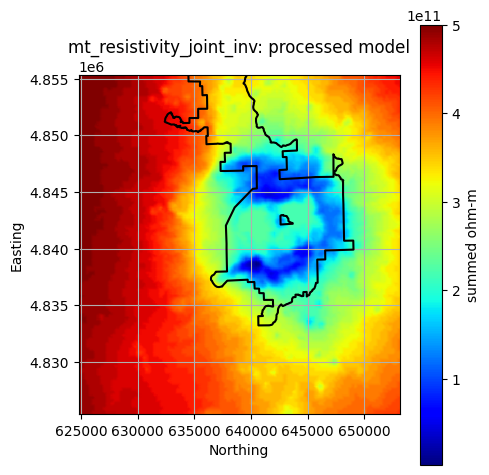

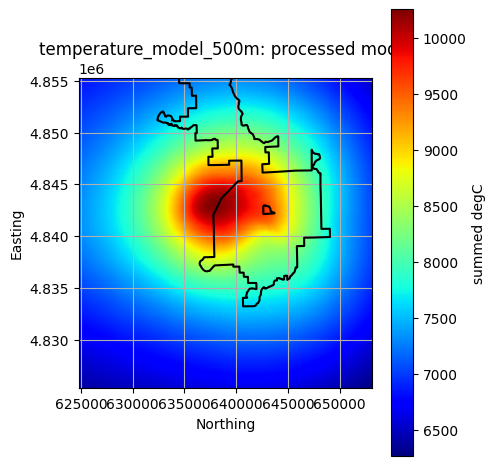

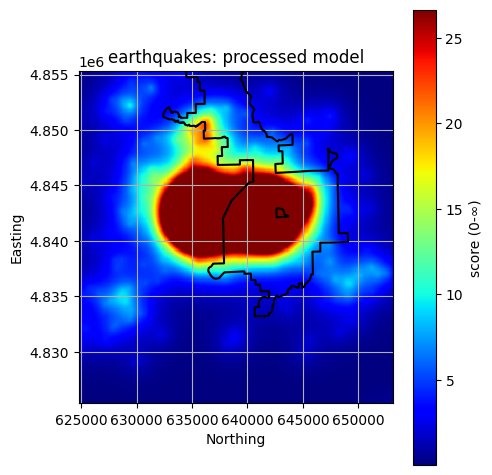

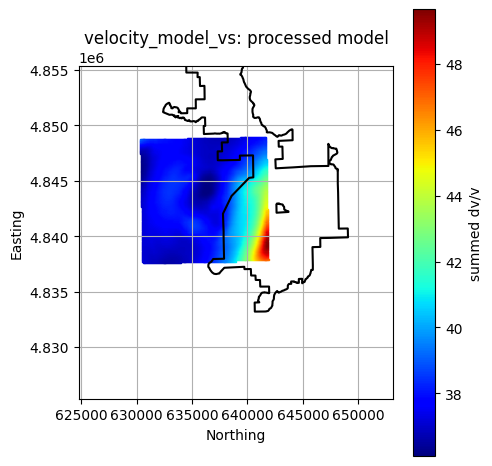

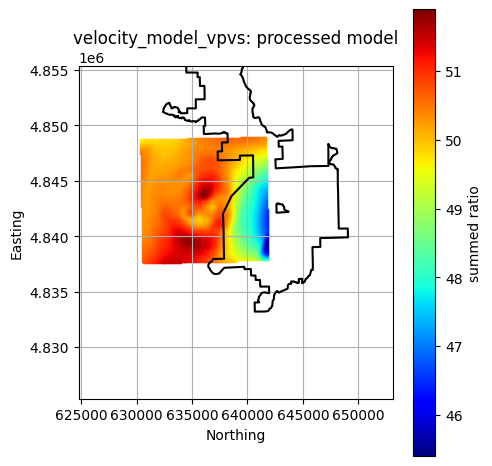

	reservoir


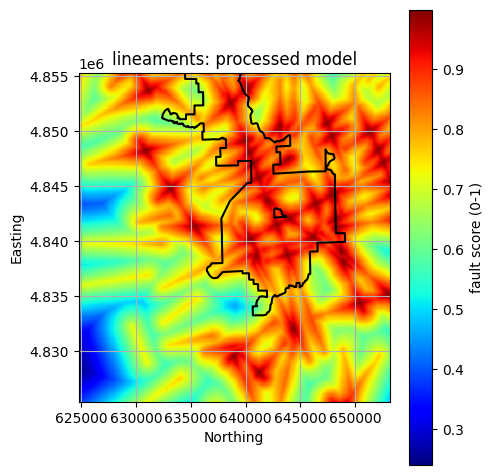

	insulation


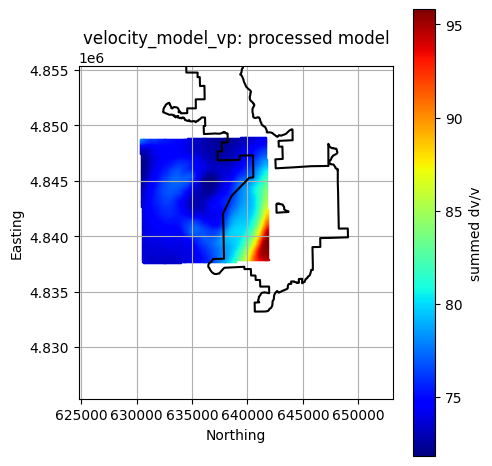


Finished plotting all available processed layers.


In [21]:
for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    plotted_layers = []

    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")

        for layer, layer_data in comp_data["layers"].items():
            if layer in plotted_layers:
                continue

            # Skip if no processed model exists
            if "model" not in layer_data or layer_data["model"] is None:
                print(f"\t\t!! Skipping {layer}: no processed 'model' found.")
                continue

            gdf = layer_data["model"]
            col = layer_data.get("model_data_col")
            units = layer_data.get("model_units", "None")
            title = f"{layer}: processed model"

            # Plot in 3D
            GeospatialDataPlotters.geo_plot(
                gdf, col, units, title, area_outline=outline, extent=extent, markersize=0.75, figsize=(5, 5)
            )

            plotted_layers.append(layer)

print("\nFinished plotting all available processed layers.")

## Save Processed Layers
It’s good practice to save processed data to disk before proceeding so processing only has to be completed once. This allows the user to make minor tweaks to the PFA, such as adjusting weights, without reprocessing all data layers.

In [22]:
for criteria, crit_data in pfa["criteria"].items():
    print(criteria)
    for component, comp_data in crit_data["components"].items():
        print(f"\t{component}")
        for layer, layer_data in comp_data["layers"].items():
            gdf = layer_data["model"]
            col = layer_data["model_data_col"]
            units = layer_data["model_units"]

            out_fp = data_dir / criteria / component / f"{layer}_processed.csv"
            gdf.to_csv(out_fp, index=False)
            print(f"\t\tSaved: {out_fp}")

geologic
	heat
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/heat/density_joint_inv_processed.csv
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/heat/mt_resistivity_joint_inv_processed.csv
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/heat/temperature_model_500m_processed.csv
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/heat/earthquakes_processed.csv
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/heat/velocity_model_vs_processed.csv
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/heat/velocity_model_vpvs_processed.csv
	reservoir
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/reservoir/density_joint_inv_processed.csv
		Saved: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/data/geologic/reservoir/mt_resistivity_joint

### Save a “Clean” PFA Config (no GeoDataFrames)
Similarly, saving a "clean" processed PFA config allows the user to avoid repeating the processing step when making minor adjustments to the PFA. This processed config serves as the config file for the next step. 

In [23]:
def drop_geodataframes(data: dict) -> dict:
    """Recursively remove GeoDataFrame objects before saving."""
    clean = {}
    for key, val in data.items():
        if isinstance(val, gpd.GeoDataFrame):
            continue
        elif isinstance(val, dict):
            clean[key] = drop_geodataframes(val)
        else:
            clean[key] = val
    return clean

pfa_nodf = drop_geodataframes(pfa)
out_json = config_dir / "newberry_superhot_processed_config.json"
with open(out_json, "w") as f:
 json.dump(pfa_nodf, f, indent=4)
print(f"Processed PFA configuration saved to: {out_json}")

Processed PFA configuration saved to: /Users/ntaverna/Documents/DEEPEN/geoPFA/examples/Newberry/2D/config/newberry_superhot_processed_config.json


## This concludes the 2D extrapolation tutorial

